# Nox Modelling

## Phase 1

In [2]:
import pandas as pd

# Load the CSV sample file
file_path = 'LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv'
df = pd.read_csv(file_path)

# Step 1: View dataset structure
print("=== Data Overview ===")
print(df.info())
print(df.head())

# Step 2: Check for missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Step 3: Unique values for categorical inspection
print("\n=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Step 4: Basic statistics
print("\n=== Descriptive Statistics ===")
print(df.describe(include='all'))

=== Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Year                  143976 non-null  int64  
 1   Grid ID 2019          143976 non-null  int64  
 2   LAEI 1km2 ID          143976 non-null  int64  
 3   Easting               143976 non-null  int64  
 4   Northing              143976 non-null  int64  
 5   Borough               143976 non-null  object 
 6   Zone                  143976 non-null  object 
 7   Main Source Category  143976 non-null  object 
 8   Sector                143976 non-null  object 
 9   Source                143976 non-null  object 
 10  bap                   31140 non-null   float64
 11  cd                    17300 non-null   float64
 12  c4h6                  34600 non-null   float64
 13  c6h6                  44980 non-null   float64
 14  ch4                   51900 no

In [4]:
import pandas as pd

# Reload the full dataset for cleaning
file_path = 'LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv'
df = pd.read_csv(file_path)

# Step 1: Drop unnecessary or low-value columns
drop_columns = [
    'Year', 'Grid ID 2019', 'LAEI 1km2 ID', 'Easting', 'Northing',
    'bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'hc', 'hcl', 'hg', 'n2o',
    'nh3', 'nmvoc', 'pb', 'pcb', 'so2', 'Emissions Unit'
]
df.drop(columns=drop_columns, inplace=True)

# Step 2: Label encode categorical features
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # Save for inverse transformation later

print("Data cleaned and encoded.")
print(df.head())

# Step 3: Show the cleaned and encoded DataFrame
df.to_csv("LAEI2019_Cleaned.csv", index=False)
print("Cleaned data saved to 'LAEI2019_Cleaned.csv'")

Data cleaned and encoded.
   Borough  Zone  Main Source Category  Sector  Source          co2       nox  \
0        6     0                     4      14      36   801.702422  0.815941   
1       19     0                     4      14      36    96.064233  0.146172   
2        5     0                     4      14      36  1654.324756  1.342779   
3       29     0                     4      14      36  1307.588067  0.933334   
4       29     1                     4      14      36   268.764076  0.225646   

       pm10     pm2.5  
0  0.202529  0.090511  
1  0.030548  0.013716  
2  0.398525  0.177336  
3  0.309936  0.137778  
4  0.050658  0.022702  
Cleaned data saved to 'LAEI2019_Cleaned.csv'


## Phase 2

In [5]:
# Load cleaned dataset
df = pd.read_csv("LAEI2019_Cleaned.csv")

# Preview missing data in NOx and CO2
print("Missing NOx:", df['nox'].isnull().sum())
print("Missing CO2:", df['co2'].isnull().sum())

# Quick preview of data structure
print(df.info())
df.head()

Missing NOx: 20760
Missing CO2: 31140
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Borough               143976 non-null  int64  
 1   Zone                  143976 non-null  int64  
 2   Main Source Category  143976 non-null  int64  
 3   Sector                143976 non-null  int64  
 4   Source                143976 non-null  int64  
 5   co2                   112836 non-null  float64
 6   nox                   123216 non-null  float64
 7   pm10                  140516 non-null  float64
 8   pm2.5                 140516 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 9.9 MB
None


,Borough,Zone,Main Source Category,Sector,Source,co2,nox,pm10,pm2.5
0,6,0,4,14,36,801.702422,0.815941,0.202529,0.090511
1,19,0,4,14,36,96.064233,0.146172,0.030548,0.013716
2,5,0,4,14,36,1654.324756,1.342779,0.398525,0.177336
3,29,0,4,14,36,1307.588067,0.933334,0.309936,0.137778
4,29,1,4,14,36,268.764076,0.225646,0.050658,0.022702


In [6]:
from sklearn.ensemble import RandomForestRegressor

# Load cleaned dataset
df = pd.read_csv("LAEI2019_Cleaned.csv")

# Step 2.1: Define features and target for NOx
features = ['co2', 'pm10', 'pm2.5', 'Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
target = 'nox'

# Step 2.2: Split into rows with known and missing NOx
nox_known = df[df['nox'].notnull()]
nox_missing = df[df['nox'].isnull()]

# Step 2.3: Prepare training data
X_train_nox = nox_known[features]
y_train_nox = nox_known[target]

# Step 2.4: Prepare prediction data
X_pred_nox = nox_missing[features]

# Step 3.1: Train the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

nox_model = RandomForestRegressor(n_estimators=100, random_state=42)
nox_model.fit(X_train_nox, y_train_nox)

# Step 3.2: Predict missing NOx values
nox_predictions = nox_model.predict(X_pred_nox)

# Step 3.3: Fill in the predicted values
df.loc[df['nox'].isnull(), 'nox'] = nox_predictions

print(" Missing NOx values imputed:", len(nox_predictions))
# Step 1: Define features and target for CO2
features_co2 = ['nox', 'pm10', 'pm2.5', 'Borough', 'Zone', 'Main Source Category', 'Sector', 'Source']
target_co2 = 'co2'

# Step 2: Split into known and missing
co2_known = df[df['co2'].notnull()]
co2_missing = df[df['co2'].isnull()]

# Step 3: Prepare training data
X_train_co2 = co2_known[features_co2]
y_train_co2 = co2_known[target_co2]

# Step 4: Drop rows where predictors are still missing
X_pred_co2 = co2_missing[features_co2].dropna()
rows_to_fill = X_pred_co2.index  # store the index to match back

# Train and predict
co2_model = RandomForestRegressor(n_estimators=100, random_state=42)
co2_model.fit(X_train_co2, y_train_co2)
co2_predictions = co2_model.predict(X_pred_co2)

# Fill only the rows we could predict
df.loc[rows_to_fill, 'co2'] = co2_predictions

print("Imputed CO2 values:", len(co2_predictions))
df.to_csv("LAEI2019_Final_Imputed.csv", index=False)

 Missing NOx values imputed: 20760
Imputed CO2 values: 27680


## Model Training

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 1: Load the cleaned, imputed dataset
df = pd.read_csv("LAEI2019_Final_Imputed.csv")

# STEP 2: Define features and target
y = df['nox']
X = df.drop(columns=['nox'])

# STEP 3: Drop rows where any predictors or target are still missing
combined = pd.concat([X, y], axis=1)
combined = combined.dropna()

# Separate again into X and y
X_clean = combined.drop(columns=['nox'])
y_clean = combined['nox']

# STEP 4: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# STEP 5: Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# STEP 6: Make predictions and evaluate
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# STEP 7: Output results
print(f" Linear Regression Model Results:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


 Linear Regression Model Results:
R² Score: 0.7504
MAE: 0.6786
RMSE: 3.2900


In [8]:
from sklearn.ensemble import RandomForestRegressor

# STEP 1: Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# STEP 2: Make predictions and evaluate
y_pred_rf = rf_model.predict(X_test)

# STEP 3: Evaluate model performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# STEP 4: Output results
print("Random Forest Regression Results:")
print(f"R² Score: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")

Random Forest Regression Results:
R² Score: 0.6306
MAE: 0.0597
RMSE: 4.0023


In [ ]:
# Evaluation of Tuned Random Forest
#Step 1: Import Required Tools and Set Up Parameter Grid
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['auto', 'sqrt']
}


#Step 2: Set Up Grid Search with Cross-Validation
# Set up the base model
rf_base = RandomForestRegressor(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='r2',  # Use R² to evaluate model fit
    n_jobs=-1,     # Use all processors for speed
    verbose=2
)

#Step 3: Run the Grid Search
# Fit the model on your training data
grid_search.fit(X_train, y_train)

#Step 4 - Check the Best Model and Re-Evaluate
# Show the best parameters
print("Best Parameters:", grid_search.best_params_)

# Use the best model to predict
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\nTuned Random Forest Results:")
print(f"R² Score: {r2_best:.4f}")
print(f"MAE: {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")

In [10]:
#NOx Prediction Using XGBoost
from xgboost import XGBRegressor

# Train the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression Results:")
print(f"R² Score: {r2_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")

XGBoost Regression Results:
R² Score: 0.7542
MAE: 0.0933
RMSE: 3.2645


<Figure size 1000x600 with 0 Axes>

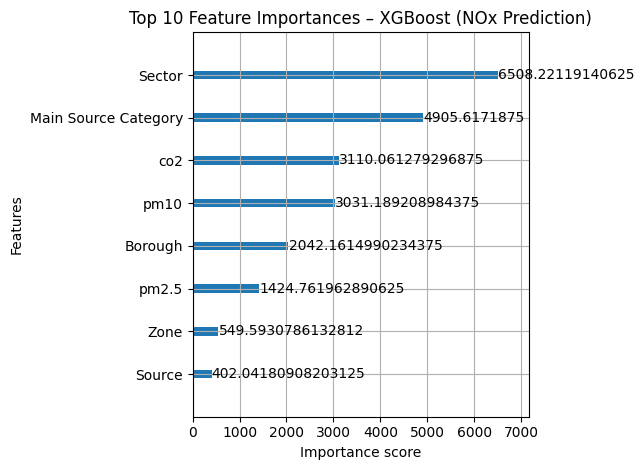

                Feature   Importance
3                Sector  6508.221191
2  Main Source Category  4905.617188
5                   co2  3110.061279
6                  pm10  3031.189209
0               Borough  2042.161499
7                 pm2.5  1424.761963
1                  Zone   549.593079
4                Source   402.041809


In [11]:
# Feature Importance – XGBoost (NOx Prediction)
# Step 1: Basic Bar Chart Using XGBoost’s Built-in Plotting
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances – XGBoost (NOx Prediction)")
plt.tight_layout()
plt.show()


# Step 2: Raw Feature Importances as a Table
# Get feature importance as dictionary
importances = xgb_model.get_booster().get_score(importance_type='gain')

# Convert to sorted list
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': list(importances.keys()),
    'Importance': list(importances.values())
}).sort_values(by='Importance', ascending=False)

print(importance_df)
